# Combining scDNA + scRNA: reconstructing subclones from expression

The two production single-cell modalities see the *same* tumour through different windows: **scDNA**
reads copy number directly, **scRNA** reads expression. The clinical trick (clonealign, inferCNV,
Numbat) is to use the **DNA-defined copy-number profiles** to make sense of the **RNA** — because a
copy-number change *doses* the genes it spans, so a subclone's CN signature leaks into its expression.

This notebook shows that link is **emergent, not imposed**. We grow *one* spatially-structured tumour,
assay it with both modalities from the same cells, and show that the CN→expression dosage relationship
*falls out of the biology*. iscc alone supplies the two pieces no real dataset has: the **true clone
label** and the **true copy number** — so we can score a from-scratch reconstruction honestly.

**The dataset is a mixture.** As in any real study, the sample is malignant cells **plus
microenvironment** (epithelial / stromal). We never filter to cancer up front — separating malignant
from normal is the *first analysis step*, and the normal cells are the diploid reference the whole
method leans on. Ground truth is used only to **score and colour**, never to pre-filter.

> The production tools do this properly — see `validation/validate_clonealign.py`,
> `validation/validate_infercnv.py`, `validation/validate_numbat.py`. Here we do a self-contained
> numpy/sklearn version to expose the *emergent signal* those tools exploit.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import iscc
from iscc.tumor.models import GenotypeTumor
from iscc.data import scRNA, scDNA
print("iscc from:", iscc.__file__)

# --- the shared spatially-structured config (structure_radius>0 => a real gland inside a normal
#     epithelial/stromal compartment; this is the config the integration benchmark uses) -----------
GENOME    = {"n_segments": 12, "segment_size": 50}
SELECTION = {"prop_driver": 0.2, "prop_dispersal": 0.0, "prop_immune_resistance": 0.0,
             "prop_treatment_resistance": 0.0}
DEME      = {"carrying_capacity": 8, "initial_cancer_cells": 4}
SPATIAL   = {"grid_size": 20, "structure_radius": 5}      # << spatial structure + normal compartment
CANCER    = {"division_rate": 0.6, "death_rate": 0.03, "max_birth_rate": 0.98,
             "mutation_rate": 1.1, "dispersal_rate": 0.5}
SEED = 3

# small self-contained helpers (per-cell coarse type; per-cell per-segment copy number)
def cell_types(t):
    gid = t.cell_data["cell_type"]["cell_id"].astype(str).values
    g = t.genotypes
    return np.array([g[x].type if x in g else "?" for x in gid])

def segment_cn(t):
    sizes = np.asarray(t.selection.segment_sizes)
    offs = np.concatenate([[0], np.cumsum(sizes)]).astype(int)
    cnv = t.cell_data["cell_cnv"].values
    seg = np.stack([cnv[:, offs[s]] for s in range(t.n_segments)], axis=1).astype(float)
    gene_seg = np.concatenate([np.full(sizes[s], s) for s in range(t.n_segments)]).astype(int)
    return seg, gene_seg

iscc from: /Users/pedroferreira/projects/iscc/repo/src/iscc/__init__.py


## 1. Grow the tumour and assemble a realistic mixture

We grow the gland, then build the **assayed sample**: *all* malignant cells + a subsample of the
microenvironment. The raw gland is ~96% normal (a spatial structure of a small tumour focus in a large
stromal field), which is an unrealistically low tumour purity; subsampling the microenvironment to
~150 cells brings us to a plausible ~50% purity while keeping the normal compartment present as the
diploid reference.

In [2]:
t = GenotypeTumor(seed=SEED, genome_params=GENOME, selection_params=SELECTION,
                  cancer_cell_params=CANCER, deme_params=DEME, spatial_params=SPATIAL)
t.grow(n_steps=1200, seed=SEED)
t.make_cell_data()
cd = t.cell_data

types = cell_types(t)
idx = np.asarray(cd["cell_exp"].index)
type_map = dict(zip(idx, types))
is_cancer = types == "cancer"
print(f"grown gland: {len(types)} cells  |  malignant {is_cancer.sum()}   "
      f"microenvironment {(~is_cancer).sum()}   raw purity {is_cancer.mean():.1%}")

# assemble the MIXTURE that every assay below consumes (all malignant + subsampled normal)
rng = np.random.default_rng(0)
cancer_cells = list(idx[is_cancer])
normal_pool  = list(idx[np.isin(types, ("epithelial", "stromal"))])
normal_cells = list(rng.choice(normal_pool, size=min(150, len(normal_pool)), replace=False))
mixture = cancer_cells + normal_cells
print(f"assayed mixture: {len(mixture)} cells  |  purity {len(cancer_cells)/len(mixture):.0%}  "
      f"(all {len(cancer_cells)} malignant + {len(normal_cells)} microenvironment)")

grown gland: 2891 cells  |  malignant 147   microenvironment 2744   raw purity 5.1%
assayed mixture: 297 cells  |  purity 49%  (all 147 malignant + 150 microenvironment)


## 2. The spatial structure

`structure_radius > 0` seeds a diploid epithelial/stromal field with the cancer focus growing inside
it. The per-cell coordinates (`cell_crd`) show the gland; the deme-level `plot_grid` shows the same
structure aggregated to the spatial lattice.

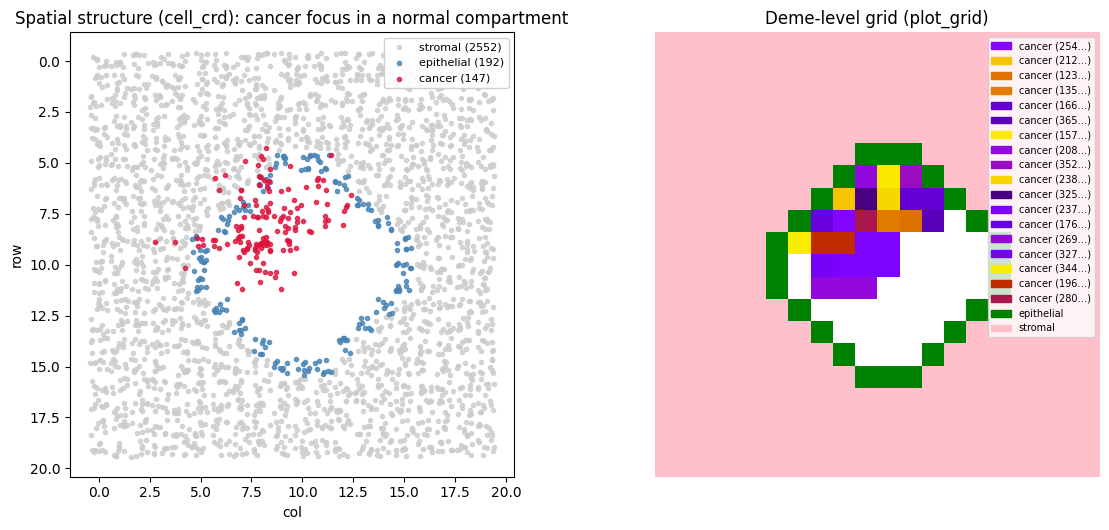

In [3]:
crd = cd["cell_crd"]
jit = np.random.default_rng(1)   # cells share deme coords; jitter to see the per-cell density
jx = crd["col"].values + jit.uniform(-0.42, 0.42, len(crd))
jy = crd["row"].values + jit.uniform(-0.42, 0.42, len(crd))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
palette = {"stromal": "0.8", "epithelial": "steelblue", "cancer": "crimson"}
for name, col in palette.items():
    m = types == name
    axes[0].scatter(jx[m], jy[m], s=9, c=col, alpha=0.8, label=f"{name} ({m.sum()})")
axes[0].set_aspect("equal"); axes[0].invert_yaxis()
axes[0].legend(loc="upper right", fontsize=8, framealpha=0.9)
axes[0].set_title("Spatial structure (cell_crd): cancer focus in a normal compartment")
axes[0].set_xlabel("col"); axes[0].set_ylabel("row")
t.plot_grid(color=["cell_type"], ax=axes[1])
axes[1].set_title("Deme-level grid (plot_grid)")
plt.tight_layout()

## 3. scRNA the mixture — malignant vs normal separate on their own

Run the F3 scRNA assay on the mixture and embed it (PCA). **Separating malignant from normal is the
real first step of any tumour scRNA pipeline** — and it works from expression alone: an unsupervised
2-cluster split recovers the true malignant/normal partition. The normal cells are not noise to be
discarded; they are the diploid reference the copy-number reasoning below depends on.

malignant vs normal separate in expression space: 2-means ARI = 0.92


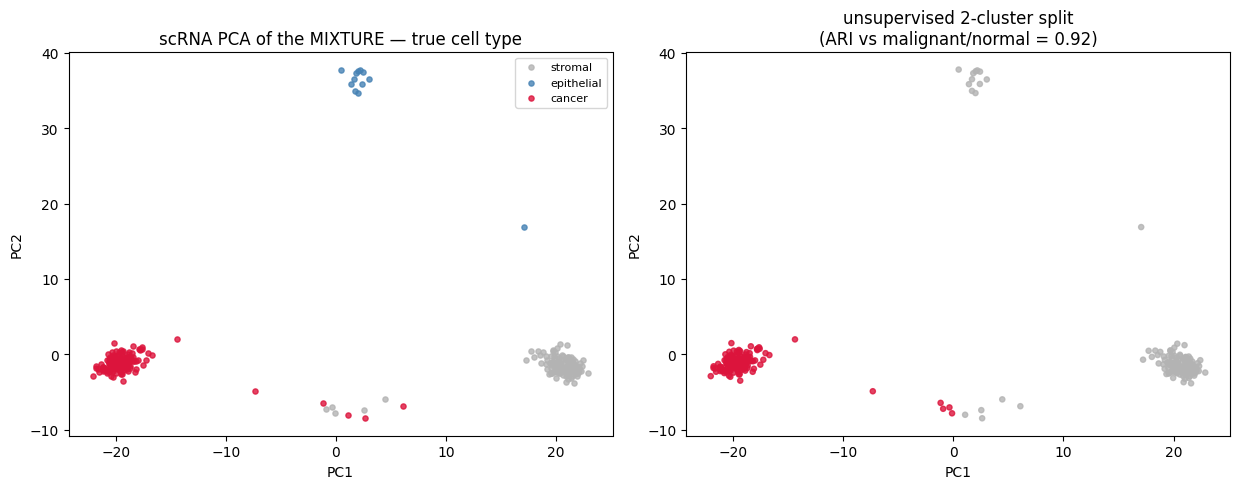

In [4]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

rna = scRNA(n_cells=len(mixture), protocol="10x", seed=1).run(cd, cell_subset=mixture)
Y = rna.observed_counts
rna_cells = list(Y.index)
is_mal = np.isin(rna_cells, cancer_cells)
type_of = np.array([type_map[c] for c in rna_cells])

Yv = Y.values.astype(float)
lib = Yv.sum(1, keepdims=True)
Ycpm = Yv / np.where(lib > 0, lib, 1.0) * 1e4               # library-normalised (linear)
Ylog = np.log1p(Ycpm)                                       # log1p, for the embedding
pcs = PCA(n_components=10, random_state=0).fit_transform(Ylog - Ylog.mean(0))
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(pcs)
ari = adjusted_rand_score(is_mal, km)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for name, col in {"stromal": "0.7", "epithelial": "steelblue", "cancer": "crimson"}.items():
    m = type_of == name
    axes[0].scatter(pcs[m, 0], pcs[m, 1], s=14, c=col, alpha=0.8, label=name)
axes[0].legend(fontsize=8); axes[0].set_title("scRNA PCA of the MIXTURE — true cell type")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].scatter(pcs[:, 0], pcs[:, 1], s=14, alpha=0.8,
                c=["crimson" if k else "0.7" for k in km])
axes[1].set_title(f"unsupervised 2-cluster split\n(ARI vs malignant/normal = {ari:.2f})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()
print(f"malignant vs normal separate in expression space: 2-means ARI = {ari:.2f}")

## 4. DNA defines the clones

Within the malignant cells (identified above), we define subclones from their **per-segment copy
number** — the standard clonealign setup, where clones and their integer CN profiles come from the DNA
modality. Agglomerative clustering on the segment-CN vectors gives a handful of clones, each with a
distinct amplification / loss.

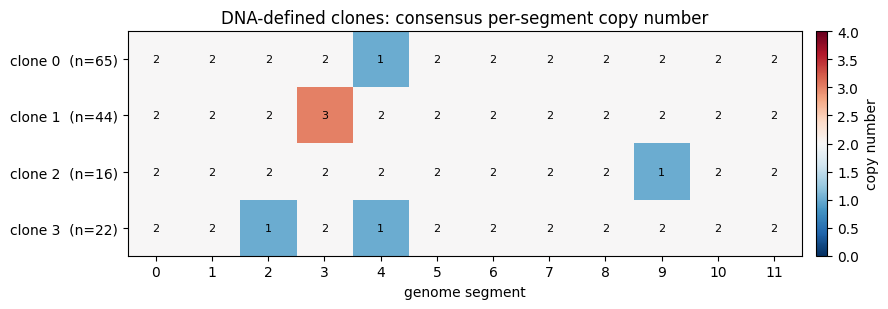

In [5]:
from sklearn.cluster import AgglomerativeClustering

seg, gene_seg = segment_cn(t)
seg_cancer = seg[is_cancer]                        # aligned to cancer_cells order
K = 4
lab = AgglomerativeClustering(n_clusters=K).fit_predict(seg_cancer)
consensus = np.stack([np.rint(seg_cancer[lab == k].mean(0)) for k in range(K)]).astype(int)
clone_of = dict(zip(cancer_cells, lab))

fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(consensus, cmap="RdBu_r", vmin=0, vmax=4, aspect="auto")
ax.set_yticks(range(K)); ax.set_yticklabels([f"clone {k}  (n={int((lab==k).sum())})" for k in range(K)])
ax.set_xlabel("genome segment"); ax.set_xticks(range(t.n_segments))
ax.set_title("DNA-defined clones: consensus per-segment copy number")
for k in range(K):
    for s in range(t.n_segments):
        ax.text(s, k, int(consensus[k, s]), ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="copy number")
plt.tight_layout()

## 5. scDNA recovers those copy-number profiles

The clone CN profiles clonealign consumes must be ones the **DNA modality actually supports**. We run
the scDNA assay on the same malignant cells and check the per-clone CN it recovers matches the truth.
(We use a deep, uniformly-amplified single-cell WGS regime — `mu_depth=200, kappa=200`, like a good
DLP+ run — so the copy-number ladder is clean; the *lumpy* low-`kappa` default and its ADO artifacts
are explored in `notebooks/assay_dna.ipynb`.)

scDNA per-clone CN concordance with the DNA-defined truth: 98%


/var/folders/d4/tfj5y66n2zzddb2k40xhyhk80000gp/T/ipykernel_56616/1589884771.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


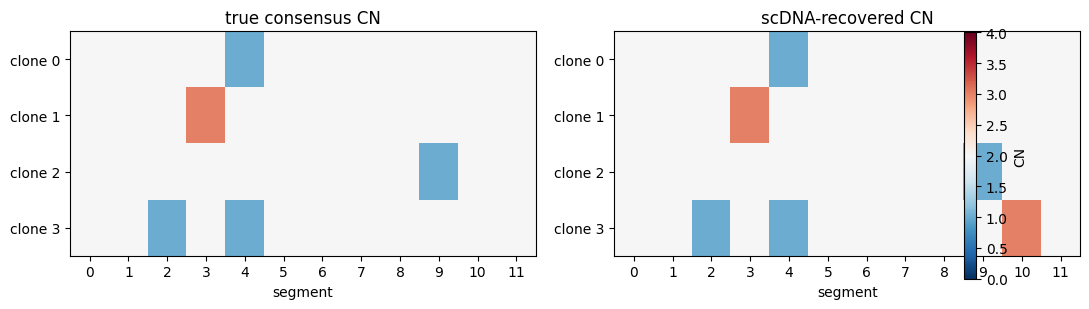

In [6]:
dna = scDNA(n_cells=len(cancer_cells), breadth="wgs", seed=7,
            mu_depth=200.0, kappa=200.0).run(cd, cell_subset=cancer_cells)
seg_ids = np.array([int(g.split("_")[1]) for g in dna.genes])
cov = dna.coverage.values.astype(float)
seg_cov = np.stack([cov[:, seg_ids == s].mean(1) for s in range(t.n_segments)], axis=1)
med = np.median(seg_cov, axis=1, keepdims=True)
obs_cn = 2.0 * seg_cov / np.where(med > 0, med, 1.0)         # normalise to a diploid baseline
dna_lab = np.array([clone_of[c] for c in dna.cells])
recovered = np.stack([np.rint(np.median(obs_cn[dna_lab == k], axis=0)) for k in range(K)]).astype(int)
conc = (recovered == consensus).mean()
print(f"scDNA per-clone CN concordance with the DNA-defined truth: {conc:.0%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, mat, title in zip(axes, [consensus, recovered], ["true consensus CN", "scDNA-recovered CN"]):
    im = ax.imshow(mat, cmap="RdBu_r", vmin=0, vmax=4, aspect="auto")
    ax.set_yticks(range(K)); ax.set_yticklabels([f"clone {k}" for k in range(K)])
    ax.set_xlabel("segment"); ax.set_xticks(range(t.n_segments)); ax.set_title(title)
plt.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="CN")
plt.tight_layout()

## 6. The emergent CN → expression link

Nothing in the assay ties expression to copy number by hand. Yet if we take, for each clone, the mean
library-normalised expression of each genome segment and plot it against that segment's **true copy
number**, the two track each other — a **dosage** relationship that *emerged* from the per-allele
expression model. The normal cells sit at the CN≈2 baseline, the anchor a dosage method calibrates
against.

per-segment mean expression vs true CN across clones: Pearson r = 0.51


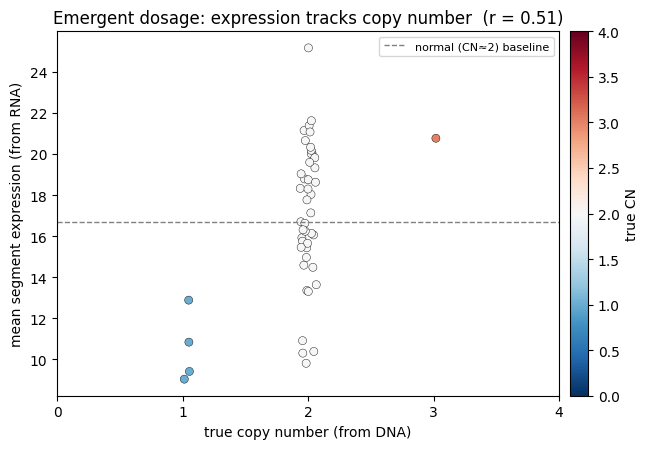

In [7]:
gi = {g: i for i, g in enumerate(list(cd["cell_exp"].columns))}
gseg = np.array([gene_seg[gi[g]] for g in Y.columns])
# dosage is (roughly) linear in copy number, so use the LINEAR library-normalised expression
segexp = np.stack([Ycpm[:, gseg == s].mean(1) for s in range(t.n_segments)], axis=1)
rna_clone = np.array([clone_of.get(c, -1) for c in rna_cells])

xs, ys = [], []
for k in range(K):
    m = rna_clone == k
    for s in range(t.n_segments):
        xs.append(consensus[k, s]); ys.append(segexp[m, s].mean())
xs, ys = np.array(xs, float), np.array(ys)
baseline = segexp[~is_mal].mean()      # normal-cell expression baseline (CN ~ 2)
r = np.corrcoef(xs, ys)[0, 1]

fig, ax = plt.subplots(figsize=(6.6, 4.6))
jt = np.random.default_rng(2).uniform(-0.07, 0.07, len(xs))
sc = ax.scatter(xs + jt, ys, s=34, c=xs, cmap="RdBu_r", vmin=0, vmax=4, edgecolor="k", lw=0.3)
ax.axhline(baseline, color="grey", ls="--", lw=1, label="normal (CN≈2) baseline")
ax.set_xlabel("true copy number (from DNA)"); ax.set_ylabel("mean segment expression (from RNA)")
ax.set_title(f"Emergent dosage: expression tracks copy number  (r = {r:.2f})")
ax.set_xticks([0, 1, 2, 3, 4]); ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02, label="true CN")
plt.tight_layout()
print(f"per-segment mean expression vs true CN across clones: Pearson r = {r:.2f}")

## 7. Reconstruct the clones from RNA alone

Now the payoff (clonealign's idea, stripped to its core): assign each **malignant** RNA cell to the
clone whose **DNA copy-number profile** best matches its per-segment expression. This uses *only* the
RNA counts plus the DNA-defined CN profiles — never the true RNA-cell clone label — and we score it
against that held-out truth.

clone reconstructed from RNA alone (nearest DNA CN profile): accuracy 63%   (chance 25%)   ARI 0.23


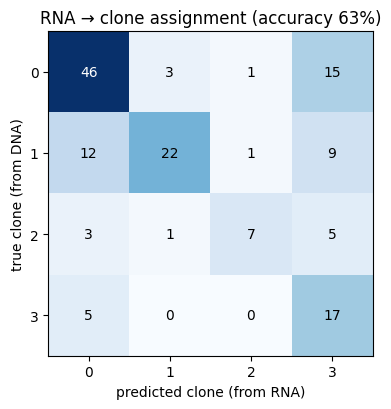

In [8]:
from scipy.optimize import linear_sum_assignment

mal_pos = np.where(is_mal)[0]
pred = []
for i in mal_pos:
    cors = [np.corrcoef(segexp[i], consensus[k])[0, 1] for k in range(K)]
    pred.append(int(np.nanargmax(cors)))
pred = np.array(pred)
truth = rna_clone[mal_pos]

# match predicted labels to true clone ids by the best permutation, then score
M = np.zeros((K, K))
for a in range(K):
    for b in range(K):
        M[a, b] = ((truth == a) & (pred == b)).sum()
r_, c_ = linear_sum_assignment(-M)
remap = {c_[i]: r_[i] for i in range(K)}
pred_m = np.array([remap[p] for p in pred])
acc = (pred_m == truth).mean()
ari2 = adjusted_rand_score(truth, pred)
print(f"clone reconstructed from RNA alone (nearest DNA CN profile): "
      f"accuracy {acc:.0%}   (chance {1/K:.0%})   ARI {ari2:.2f}")

CM = np.zeros((K, K), int)
for tr, pr in zip(truth, pred_m):
    CM[tr, pr] += 1
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(CM, cmap="Blues")
for a in range(K):
    for b in range(K):
        ax.text(b, a, CM[a, b], ha="center", va="center",
                color="white" if CM[a, b] > CM.max() / 2 else "black")
ax.set_xlabel("predicted clone (from RNA)"); ax.set_ylabel("true clone (from DNA)")
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_title(f"RNA → clone assignment (accuracy {acc:.0%})")
plt.tight_layout()

## What this shows

* One spatially-structured tumour, assayed by **scDNA and scRNA from the same cells**, gives a
  labelled multi-modal benchmark: true clone, true CN, and both observed modalities.
* The **CN → expression dosage link is emergent** — it is a consequence of the per-allele expression
  model, not something the assay imposes — which is exactly what makes clonealign / inferCNV / Numbat
  possible on real data.
* A bare-bones nearest-CN-profile reconstruction assigns malignant RNA cells to their DNA-defined
  clone well above chance. It is deliberately *simple*: the number is an honest floor on the emergent
  signal, **not** a tool result. The production methods (which model the count distribution, the
  library size, and a phylogeny prior) do much better.

**Next / see also:**
[`notebooks/assay_dna.ipynb`](assay_dna.ipynb) (the DNA coverage/VAF/ADO model in depth) ·
[`notebooks/assay_scrna.ipynb`](assay_scrna.ipynb) (the scRNA batch model) ·
[`notebooks/wgd_allele_cna.ipynb`](wgd_allele_cna.ipynb) (whole-genome doubling + the allele layer) ·
the real tool benchmarks under `validation/` (`validate_clonealign.py`, `validate_infercnv.py`,
`validate_numbat.py`).